# Lab - 8

Using device: cuda


100%|██████████| 170M/170M [00:04<00:00, 39.9MB/s]


Training DCGAN...
Epoch 1/50  Loss D: 0.6851  Loss G: 1.4586
Epoch 2/50  Loss D: 0.2566  Loss G: 3.0150
Epoch 3/50  Loss D: 0.2861  Loss G: 2.4705
Epoch 4/50  Loss D: 0.2771  Loss G: 4.6524
Epoch 5/50  Loss D: 0.1884  Loss G: 6.2053
Epoch 6/50  Loss D: 0.1728  Loss G: 7.9472
Epoch 7/50  Loss D: 0.8098  Loss G: 5.2966
Epoch 8/50  Loss D: 0.1822  Loss G: 5.2563
Epoch 9/50  Loss D: 0.3967  Loss G: 2.7704
Epoch 10/50  Loss D: 0.2510  Loss G: 2.7264
Epoch 11/50  Loss D: 0.3777  Loss G: 3.8485
Epoch 12/50  Loss D: 0.3219  Loss G: 4.2702
Epoch 13/50  Loss D: 0.1888  Loss G: 4.9001
Epoch 14/50  Loss D: 0.1907  Loss G: 9.2422
Epoch 15/50  Loss D: 0.2170  Loss G: 5.5175
Epoch 16/50  Loss D: 0.1733  Loss G: 5.6492
Epoch 17/50  Loss D: 0.1755  Loss G: 7.0352
Epoch 18/50  Loss D: 0.2577  Loss G: 5.3634
Epoch 19/50  Loss D: 0.1811  Loss G: 5.5286
Epoch 20/50  Loss D: 0.1730  Loss G: 5.5159
Epoch 21/50  Loss D: 0.1670  Loss G: 8.1116
Epoch 22/50  Loss D: 0.1756  Loss G: 4.8446
Epoch 23/50  Loss D: 0.

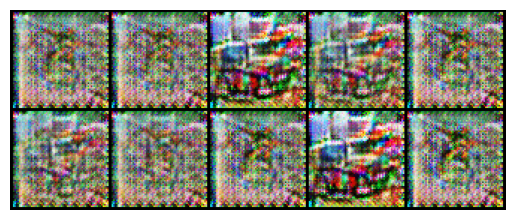

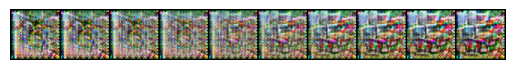

Done


In [ ]:
!pip install torch torchvision matplotlib numpy pillow --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("outputs", exist_ok=True)

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

latent_dim = 100
lr = 0.0002
epochs = 50

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, latent_dim, 1, 1).to(device)

print("Training DCGAN...")

for epoch in range(epochs):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size).to(device) * 0.9
        fake_labels = torch.zeros(batch_size).to(device)

        noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake = G(noise)

        loss_real = criterion(D(real), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)
        loss_D = (loss_real + loss_fake) / 2

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        output = D(fake)
        loss_G = criterion(output, torch.ones(batch_size).to(device))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss D: {loss_D:.4f}  Loss G: {loss_G:.4f}")

    with torch.no_grad():
        fake_images = G(fixed_noise)
        save_image((fake_images + 1)/2, f"outputs/progress_{epoch+1}.png", nrow=4)

print("Training complete")

with torch.no_grad():
    noise = torch.randn(10, latent_dim, 1, 1).to(device)
    images = G(noise)
    save_image((images + 1)/2, "outputs/random_samples.png", nrow=5)

def interpolate(z1, z2, steps=10):
    result = []
    for alpha in torch.linspace(0, 1, steps):
        z = (1 - alpha) * z1 + alpha * z2
        result.append(z)
    return torch.cat(result)

z1 = torch.randn(1, latent_dim, 1, 1).to(device)
z2 = torch.randn(1, latent_dim, 1, 1).to(device)

interp = interpolate(z1, z2, 10)

with torch.no_grad():
    images = G(interp)
    save_image((images + 1)/2, "outputs/interpolation.png", nrow=10)

def show_image(path):
    img = plt.imread(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_image("outputs/random_samples.png")
show_image("outputs/interpolation.png")

print("Done")